In [1]:
import torch
import matplotlib.pyplot as plt

# **Proceso Poisson**

In [9]:
class PoissonProcess1:
    """
    Simulación de un proceso de Poisson homogéneo usando tiempos entre llegadas
    exponenciales.

    Parámetros
    ----------
    lam : float
        Intensidad (tasa) λ del proceso de Poisson.

    Métodos
    -------
    simulate(t)
        Simula el proceso hasta tiempo t y devuelve los tiempos de llegada
        y el número total de eventos.

    plot(t, color="blue", linestyle="-", marker=None)
        Grafica una trayectoria del proceso de Poisson hasta tiempo t.
    """

    def __init__(self, lam):
        """
        Constructor del proceso de Poisson.

        Parámetros
        ----------
        lam : float
            Intensidad λ del proceso.
        """

        # Guardamos la tasa λ
        self.lam = lam 
        
        # Distribución exponencial para los tiempos entre llegadas
        self.expo = torch.distributions.Exponential(self.lam) 


    def simulate(self, t):
        """
        Simula el proceso de Poisson hasta tiempo t.

        Parámetros
        ----------
        t : float
            Tiempo final de simulación.

        Retorna
        -------
        S : torch.Tensor
            Tensor con los tiempos de llegada.
        n : int
            Número total de eventos ocurridos hasta tiempo t.
        """

        time = 0          # tiempo actual del proceso
        S = []            # lista de tiempos de llegada
        
        while True:

            # Generamos un tiempo entre llegadas ~ Exp(λ)
            T = self.expo.sample().item()
            
            # Actualizamos el tiempo acumulado
            time += T 

            # Si excede el horizonte t, terminamos
            if time > t:
                break
            
            # Guardamos el tiempo de llegada
            S.append(time)

        # Convertimos a tensor
        S = torch.tensor(S)
        
        # Número de eventos
        n = len(S)
        
        return S, n


    def plot(self, t, color="blue", linestyle="-", marker=None):
        """
        Grafica una trayectoria del proceso de Poisson N(t).

        Parámetros
        ----------
        t : float
            Tiempo final.
        color : str, opcional
            Color de la gráfica.
        linestyle : str, opcional
            Estilo de línea.
        marker : str, opcional
            Marcador de los puntos.
        """
       
        # Simulamos una trayectoria
        S, n = self.simulate(t)

        # Tiempos para el escalón (incluimos 0 y el tiempo final t)
        times = torch.cat((torch.tensor([0.0]), S, torch.tensor([t])))
        
        # Valores del conteo N(t)
        counts = torch.arange(0, n + 1)
        counts = torch.cat((counts, torch.tensor([n])))

        # Gráfica tipo escalón (propia de procesos de conteo)
        plt.figure()
        plt.step(times, counts, where="post",
                 color=color,
                 linestyle=linestyle,
                 marker=marker)

        plt.xlabel("t")
        plt.ylabel("N(t)")
        plt.title(f"Proceso de Poisson (λ={self.lam})")
        plt.show()

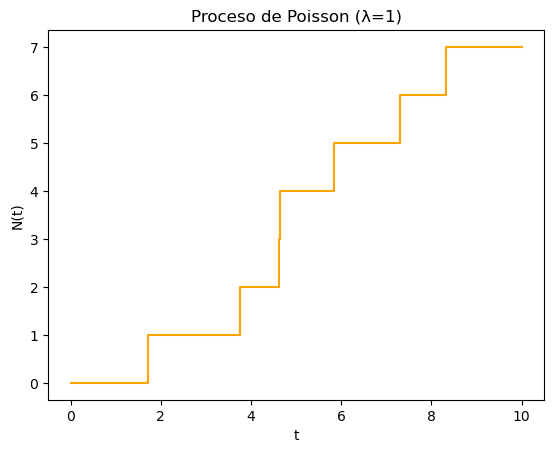

In [10]:
poi_p = PoissonProcess1(1)
poi_p.plot(10,color='orange',linestyle="-")

In [11]:
class PoissonProcess2:
    """
    Simulación de un proceso de Poisson homogéneo usando incrementos
    Poisson en una malla de tiempo uniforme.

    Parámetros
    ----------
    lam : float
        Intensidad (tasa) λ del proceso de Poisson.

    Métodos
    -------
    simulate(t, n)
        Simula el proceso en una malla uniforme de n intervalos hasta tiempo t.

    plot(t, n, color="blue", linestyle="-", marker=None)
        Grafica una trayectoria del proceso.
    """

    def __init__(self, lam):
        """
        Constructor del proceso de Poisson.

        Parámetros
        ----------
        lam : float
            Intensidad λ del proceso.
        """

        # Guardamos la tasa λ
        self.lam = lam
        
        
    def simulate(self, t, n):
        """
        Simula el proceso de Poisson en una malla uniforme.

        Parámetros
        ----------
        t : float
            Tiempo final.
        n : int
            Número de intervalos de la malla.

        Retorna
        -------
        times : torch.Tensor
            Malla de tiempos uniforme en [0, t].
        N : torch.Tensor
            Valores del proceso de conteo N(t) en la malla.
        """

        # Malla uniforme de tiempos
        times = torch.linspace(0, t, n + 1)

        # Vector para almacenar el proceso
        N = torch.zeros(n + 1)

        # Longitud de cada intervalo
        delta = t / n  

        # Simulación de incrementos independientes
        for i in range(1, n + 1):

            # Incremento ~ Poisson(λ Δt)
            X = torch.distributions.Poisson(self.lam * delta).sample()
            
            # Propiedad de incrementos independientes
            N[i] = N[i - 1] + X

        return times, N


    def plot(self, t, n, color="blue", linestyle="-", marker=None):
        """
        Grafica una trayectoria del proceso de Poisson.

        Parámetros
        ----------
        t : float
            Tiempo final.
        n : int
            Número de intervalos de la malla.
        color : str, opcional
            Color de la gráfica.
        linestyle : str, opcional
            Estilo de línea.
        marker : str, opcional
            Marcador de puntos.
        """

        # Simulamos trayectoria
        times, N = self.simulate(t, n)

        # Gráfica tipo escalón
        plt.figure()
        plt.step(
            times,
            N,
            where="post",
            color=color,
            linestyle=linestyle,
            marker=marker,
        )

        plt.xlabel("t")
        plt.ylabel("N(t)")
        plt.title(f"Proceso de Poisson (λ={self.lam})")
        plt.show()

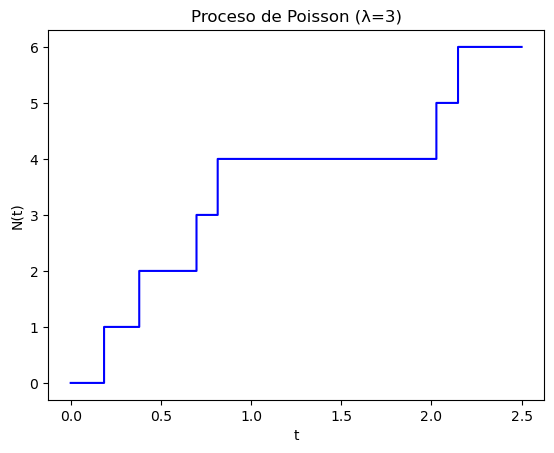

In [16]:
poi_p2 = PoissonProcess2(3)
poi_p2.plot(2.5,1000)

In [17]:
class PoissonProcess3:
    """
    Simulación de un proceso de Poisson homogéneo usando el método
    de ordenamiento de uniformes (propiedad condicional del proceso).

    Idea:
    -----
    1. Primero se simula el número total de eventos:
           N ~ Poisson(λ tf)
    2. Condicionalmente a N, los tiempos de llegada son iid Uniformes(0, tf)
    3. Se ordenan los tiempos para obtener la trayectoria.

    Parámetros
    ----------
    lam : float
        Intensidad (tasa) λ del proceso de Poisson.

    Métodos
    -------
    simulate(tf)
        Simula los tiempos de llegada hasta tiempo final tf.

    plot(tf, color="blue", linestyle="-", marker=None)
        Grafica una trayectoria del proceso.
    """

    def __init__(self, lam):
        """
        Constructor del proceso de Poisson.

        Parámetros
        ----------
        lam : float
            Intensidad λ del proceso.
        """

        # Guardamos la tasa λ
        self.lam = lam


    def simulate(self, tf):
        """
        Simula el proceso de Poisson en el intervalo [0, tf]
        usando el método de ordenamiento de uniformes.

        Parámetros
        ----------
        tf : float
            Tiempo final.

        Retorna
        -------
        S : torch.Tensor
            Tiempos de llegada ordenados.
        N : int
            Número total de eventos en [0, tf].
        """

        # Paso 1: número total de saltos
        # N ~ Poisson(λ tf)
        N = int(torch.distributions.Poisson(self.lam * tf).sample().item())

        # Paso 2: tiempos de llegada sin ordenar
        # Uniformes en [0, tf]
        U = torch.rand(N) * tf

        # Paso 3: ordenar tiempos
        S = torch.sort(U).values

        return S, N


    def plot(self, tf, color="blue", linestyle="-", marker=None):
        """
        Grafica una trayectoria del proceso de Poisson.

        Parámetros
        ----------
        tf : float
            Tiempo final.
        color : str, opcional
            Color de la gráfica.
        linestyle : str, opcional
            Estilo de línea.
        marker : str, opcional
            Marcador de puntos.
        """

        # Simulamos trayectoria
        S, N = self.simulate(tf)

        # Construcción del proceso escalonado N(t)
        times = torch.cat((torch.tensor([0.0]), S, torch.tensor([tf])))
        
        counts = torch.arange(0, N + 1)
        counts = torch.cat((counts, torch.tensor([N])))

        # Gráfica tipo escalón
        plt.figure()
        plt.step(
            times,
            counts,
            where="post",
            color=color,
            linestyle=linestyle,
            marker=marker,
        )

        plt.xlabel("t")
        plt.ylabel("N(t)")
        plt.title(f"Proceso de Poisson (λ={self.lam})")
        plt.show()

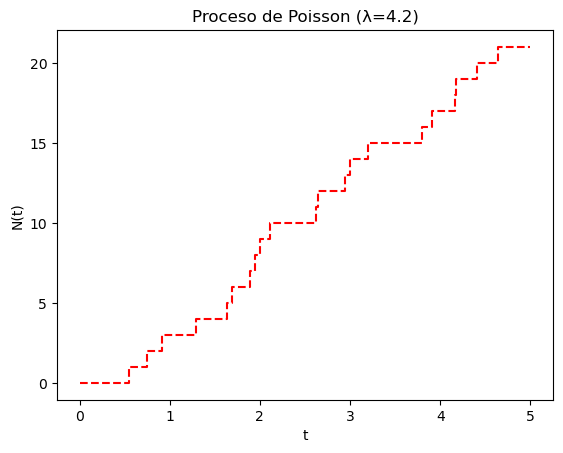

In [18]:
pp = PoissonProcess3(lam=4.2)
pp.plot(tf=5.0, color="red", linestyle="--")

In [21]:
# Generar números aleatorios para una distribución específica
class LogUniform(torch.distributions.Distribution):

    def __init__(self):

        super().__init__(validate_args=False)

    def sample(self, sample_shape=torch.Size()):
        U = torch.rand(sample_shape)
        return torch.exp(U)
        

In [22]:
cd = LogUniform()

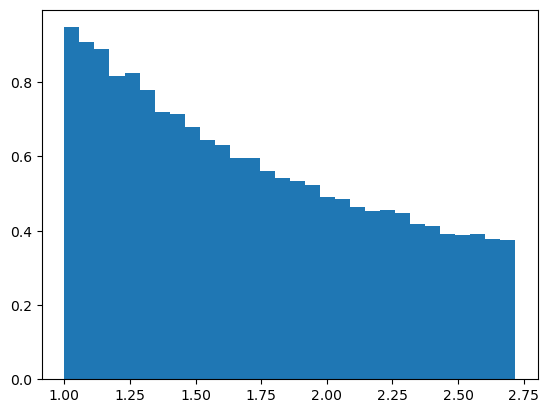

In [27]:
x = cd.sample(torch.Size([100000]))
plt.hist(x,density=True,bins=30)
plt.show()